<a href="https://colab.research.google.com/github/AabhinavAnand/Netflix-Data-Visualization-/blob/main/netflixdataanalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# Install libraries (most are pre-installed in Colab)
!pip install pandas numpy matplotlib seaborn plotly -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.facecolor'] = '#141414'
plt.rcParams['axes.facecolor'] = '#1f1f1f'
plt.rcParams['text.color'] = 'white'
plt.rcParams['axes.labelcolor'] = 'white'
plt.rcParams['xtick.color'] = 'white'
plt.rcParams['ytick.color'] = 'white'
plt.rcParams['axes.edgecolor'] = '#444'

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [6]:
# Working URL from Kaggle's official mirror

df = pd.read_csv("/content/netflix_titles.csv")

print(f"Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (8807, 12)

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']

First 3 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [7]:
# Drop duplicates
df.drop_duplicates(inplace=True)

# Fill missing values
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['date_added'].fillna('January 1, 2000', inplace=True)

# Parse date
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Primary country
df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0].strip())

print("✅ Data cleaned!")
print(df.isnull().sum())

✅ Data cleaned!
show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added         0
release_year       0
rating             0
duration           3
listed_in          0
description        0
year_added         0
month_added        0
primary_country    0
dtype: int64


In [8]:
print("=" * 45)
print("       NETFLIX DATA ANALYSIS SUMMARY")
print("=" * 45)
print(f"  Total Titles     : {len(df):,}")
print(f"  Movies           : {len(df[df['type']=='Movie']):,}")
print(f"  TV Shows         : {len(df[df['type']=='TV Show']):,}")
print(f"  Countries        : {df['primary_country'].nunique()}")
print(f"  Directors        : {df['director'].nunique()}")
print(f"  Date Range       : {df['year_added'].min()} – {df['year_added'].max()}")
print("=" * 45)

       NETFLIX DATA ANALYSIS SUMMARY
  Total Titles     : 8,807
  Movies           : 6,131
  TV Shows         : 2,676
  Countries        : 87
  Directors        : 4529
  Date Range       : 2000 – 2021


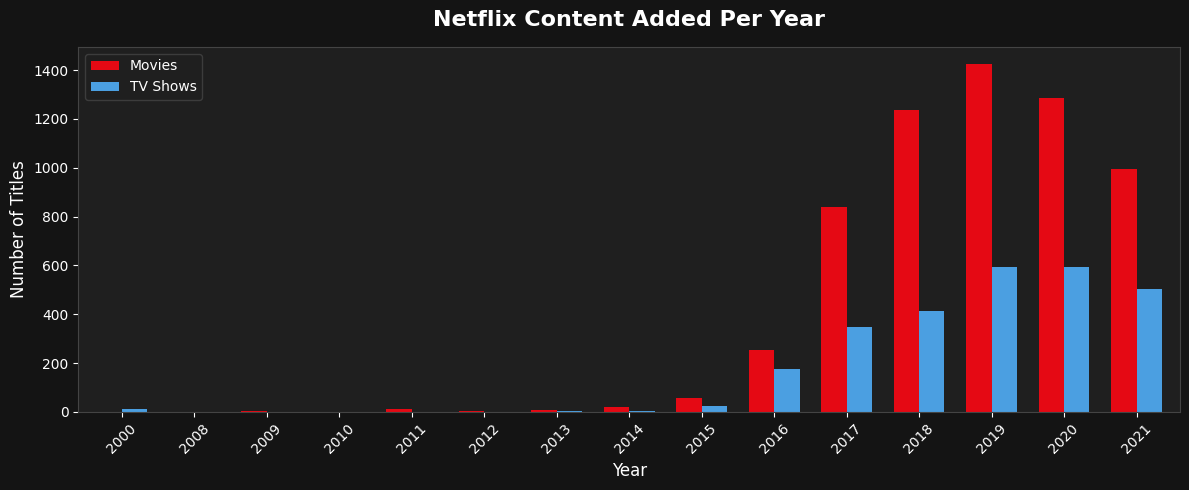

✅ Chart saved!


In [9]:
fig, ax = plt.subplots(figsize=(12, 5))

yearly = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly.plot(kind='bar', ax=ax, color=['#E50914', '#4B9FE1'], width=0.7, edgecolor='none')

ax.set_title('Netflix Content Added Per Year', fontsize=16, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.legend(['Movies', 'TV Shows'], facecolor='#1f1f1f', edgecolor='#444', labelcolor='white')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('content_per_year.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

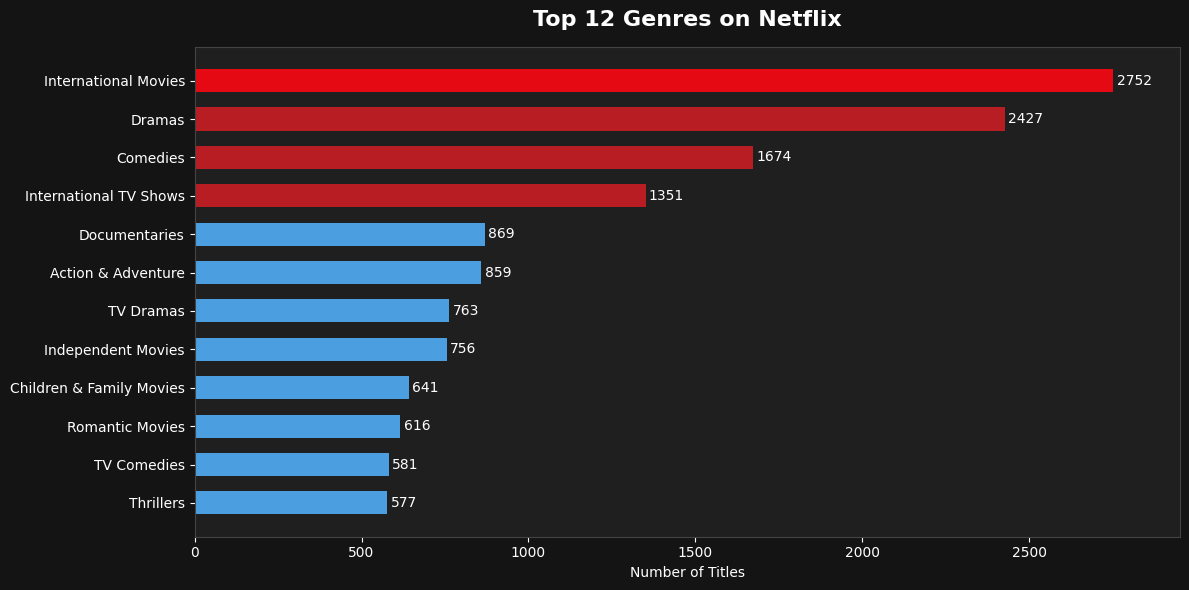

In [10]:
# Explode genres
genres = df['listed_in'].str.split(',').explode().str.strip()
top_genres = genres.value_counts().head(12)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#E50914'] + ['#B81D24'] * 3 + ['#4B9FE1'] * 8
bars = ax.barh(top_genres.index[::-1], top_genres.values[::-1], color=colors[::-1], edgecolor='none', height=0.6)

for bar, val in zip(bars, top_genres.values[::-1]):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            str(val), va='center', color='white', fontsize=10)

ax.set_title('Top 12 Genres on Netflix', fontsize=16, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Number of Titles')
ax.set_xlim(0, top_genres.max() + 200)
plt.tight_layout()
plt.savefig('top_genres.png', dpi=150, bbox_inches='tight')
plt.show()

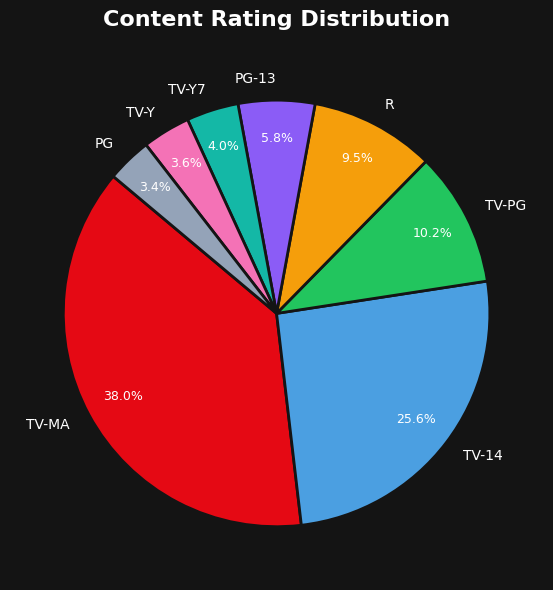

In [11]:
ratings = df['rating'].value_counts().head(8)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E50914','#4B9FE1','#22c55e','#f59e0b','#8b5cf6','#14b8a6','#f472b6','#94a3b8']
wedges, texts, autotexts = ax.pie(
    ratings.values, labels=ratings.index,
    autopct='%1.1f%%', colors=colors,
    startangle=140, pctdistance=0.82,
    wedgeprops=dict(edgecolor='#141414', linewidth=2)
)
for t in texts: t.set_color('white')
for at in autotexts: at.set_color('white'); at.set_fontsize(9)

ax.set_title('Content Rating Distribution', fontsize=16, fontweight='bold', color='white', pad=15)
plt.tight_layout()
plt.savefig('ratings_pie.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
top_countries = df['primary_country'].value_counts().head(15).reset_index()
top_countries.columns = ['Country', 'Count']

fig = px.bar(
    top_countries, x='Count', y='Country',
    orientation='h', color='Count',
    color_continuous_scale=['#4B0082','#E50914'],
    title='Top 15 Content Producing Countries',
    text='Count'
)
fig.update_layout(
    plot_bgcolor='#141414', paper_bgcolor='#141414',
    font_color='white', title_font_size=16,
    coloraxis_showscale=False, yaxis=dict(autorange='reversed')
)
fig.update_traces(textposition='outside', textfont_color='white')
fig.show()

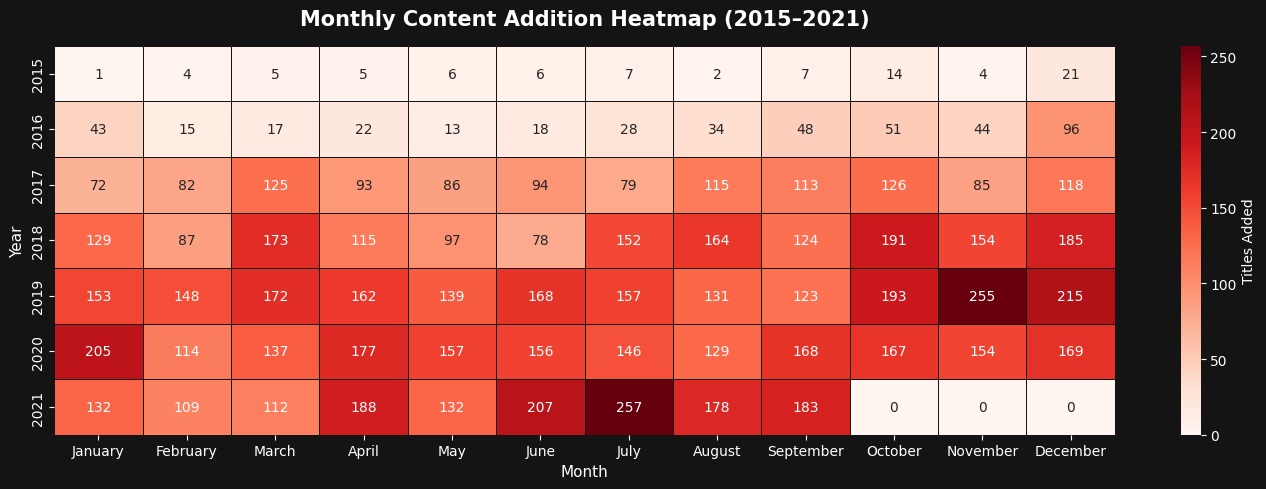

In [13]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = df.groupby(['year_added','month_added']).size().unstack(fill_value=0)
monthly = monthly.reindex(columns=month_order, fill_value=0)
monthly = monthly[monthly.index >= 2015]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(monthly, cmap='Reds', linewidths=0.5, linecolor='#141414',
            annot=True, fmt='d', ax=ax,
            cbar_kws={'label': 'Titles Added'})

ax.set_title('Monthly Content Addition Heatmap (2015–2021)', fontsize=15, fontweight='bold', color='white', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Year', fontsize=11)
plt.tight_layout()
plt.savefig('monthly_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
movies = df[df['type'] == 'Movie']
shows = df[df['type'] == 'TV Show']

print("=" * 50)
print("         TOP ANALYST INSIGHTS")
print("=" * 50)
print(f"\n📌 Most common rating    : {df['rating'].mode()[0]}")
print(f"📌 Top producing country : {df['primary_country'].value_counts().index[0]}")
print(f"📌 Peak content year     : {int(df['year_added'].value_counts().index[0])}")
print(f"📌 Best month to release : {df['month_added'].value_counts().index[0]}")
print(f"📌 Avg movie duration    : {movies['duration'].str.extract(r'(\d+)')[0].astype(float).mean():.0f} mins")
print(f"📌 Most common TV seasons: {shows['duration'].value_counts().index[0]}")
print(f"📌 Top genre             : {genres.value_counts().index[0]}")
print("=" * 50)

         TOP ANALYST INSIGHTS

📌 Most common rating    : TV-MA
📌 Top producing country : United States
📌 Peak content year     : 2019
📌 Best month to release : July
📌 Avg movie duration    : 100 mins
📌 Most common TV seasons: 1 Season
📌 Top genre             : International Movies
